# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from datetime import date

# Get Current Year

In [ ]:
# calculate current year dynamically to be used further on
current_date = date.today()
current_year = current_date.year
print('Current Year: ', current_year)

Current Year:  2026


# Loading data
replacing spaces in cells with nan, naming columns

In [15]:
df_raw= pd.read_excel("ToR Structures_Data_Updated- bahman 1405.xlsx", skiprows = 2, header=None)
df_trim = df_raw.replace(r"^\s*$", np.nan, regex=True)

In [16]:
df_trim.columns = [
    "Structure_ID",
    "Bridge_Cat",
    "Hwy_ID",
    "Hwy_Dir",
    "KM",
    "Usage_Code",
    "Replacement_Cost",
    "First_Year_In_Service",
    "Unique_Span_Type",
    "Max_Span_Ln",
    "No_of_Spans",
    "Nominal_Bridge_Ln",
    "Total_Clear_Roadway",
    "Cond_Rat_Deck",  # به جای Cond Rat ادغام شده اول
    "Cond_Rat_Super",  # به جای Unnamed: 14
    "Cond_Rat_Sub",  # به جای Unnamed: 15
    "Insp_Date",
    "Traffic_Volume",
]

In [17]:
display(df_trim.columns.tolist())

['Structure_ID',
 'Bridge_Cat',
 'Hwy_ID',
 'Hwy_Dir',
 'KM',
 'Usage_Code',
 'Replacement_Cost',
 'First_Year_In_Service',
 'Unique_Span_Type',
 'Max_Span_Ln',
 'No_of_Spans',
 'Nominal_Bridge_Ln',
 'Total_Clear_Roadway',
 'Cond_Rat_Deck',
 'Cond_Rat_Super',
 'Cond_Rat_Sub',
 'Insp_Date',
 'Traffic_Volume']

In [18]:
display(df_trim.info())

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Structure_ID           161 non-null    str    
 1   Bridge_Cat             161 non-null    str    
 2   Hwy_ID                 161 non-null    str    
 3   Hwy_Dir                161 non-null    str    
 4   KM                     161 non-null    float64
 5   Usage_Code             109 non-null    str    
 6   Replacement_Cost       161 non-null    float64
 7   First_Year_In_Service  161 non-null    int64  
 8   Unique_Span_Type       161 non-null    str    
 9   Max_Span_Ln            161 non-null    float64
 10  No_of_Spans            161 non-null    int64  
 11  Nominal_Bridge_Ln      161 non-null    float64
 12  Total_Clear_Roadway    161 non-null    float64
 13  Cond_Rat_Deck          161 non-null    float64
 14  Cond_Rat_Super         161 non-null    float64
 15  Cond_Rat_Sub     

None

In [19]:
display(df_trim.describe().T)

,count,mean,std,min,25%,50%,75%,max
KM,161.0,1.928955e+01,1.441731e+01,0.000000,8.099000,1.603400e+01,2.955500e+01,6.090900e+01
Replacement_Cost,161.0,1.894461e+06,1.501268e+06,44744.264740,914613.985994,1.508536e+06,2.534100e+06,8.418120e+06
First_Year_In_Service,161.0,1.975969e+03,1.617190e+01,1904.000000,1965.000000,1.976000e+03,1.988000e+03,2.012000e+03
Max_Span_Ln,161.0,2.533230e+01,1.412076e+01,1.800000,14.000000,2.440000e+01,3.440000e+01,6.920000e+01
No_of_Spans,161.0,2.881988e+00,1.296046e+00,1.000000,2.000000,3.000000e+00,4.000000e+00,8.000000e+00
Nominal_Bridge_Ln,161.0,1.051723e+02,8.218746e+01,2.634279,48.823638,8.364502e+01,1.359724e+02,4.785250e+02
Total_Clear_Roadway,161.0,1.707172e+01,5.433387e+00,3.256962,13.504347,1.672336e+01,2.056729e+01,4.726920e+01
Cond_Rat_Deck,161.0,5.492538e+01,9.520578e+00,28.045364,49.601372,5.515385e+01,6.128528e+01,8.116442e+01
Cond_Rat_Super,161.0,5.825630e+01,1.067037e+01,17.942491,51.403529,5.825911e+01,6.627448e+01,8.652168e+01
Cond_Rat_Sub,161.0,4.406989e+01,9.947882e+00,17.606721,36.539790,4.408486e+01,5.178123e+01,6.757765e+01


In [20]:
display(df_trim.head(5))

,Structure_ID,Bridge_Cat,Hwy_ID,Hwy_Dir,KM,Usage_Code,Replacement_Cost,First_Year_In_Service,Unique_Span_Type,Max_Span_Ln,No_of_Spans,Nominal_Bridge_Ln,Total_Clear_Roadway,Cond_Rat_Deck,Cond_Rat_Super,Cond_Rat_Sub,Insp_Date,Traffic_Volume
0,B1,STD,135A,C,14.818,RV,2.511241e+05,1975,VS,6.1,1,11.670669,21.488884,64.093956,64.222792,43.155013,2018,15562
1,B2,MAJ,231B,C,23.774,RV,4.463536e+06,1978,VF,36.6,4,251.228128,16.919171,54.069649,71.158214,56.166394,2018,8773
2,B3,MAJ,150A,C,21.298,RV,1.019767e+06,1959,PJ,18.9,3,83.830345,11.835841,60.531122,54.210105,34.689818,2019,2277
3,B4,MAJ,135F,C,41.787,NaN,6.700095e+05,1992,SCC,12.0,3,51.404896,12.470936,54.876023,67.320241,39.173237,2017,7101
4,B5,MAJ,132B,C,11.901,RO,1.282953e+06,1958,CT,23.8,3,58.376076,20.657971,53.329184,64.345511,60.535190,2018,1840


# Calculate Current Rate Conditions

In [ ]:
bridge_types = {
  "Standard": {
    "Timber": ["TP", "TT"],
    "Prestressed": ["SCC", "SM", "SMC", "VS", "VSO"],
    "Precast": ["HC"],
  },
  "Major": {
    "Concrete": {
      "Pre_stressed_girder": ["CBC", "DBC", "CBT", "DBT", "FC", "FM", "LF", "PJ", "PM", "PO", "PQ", "RD", "RM", "VF"],
      "Pre_cast_girder": ["PE"],
      "Cast_in_place": ["CA", "CF", "CS", "CT", "CV", "CX"],
    },
    "Steel": {
      "Beam": ["FR", "WG", "RB", "RG"],
      "Truss": ["TH"],
    },
  },
}

def update_cond(old_val, year_diff):
    annual_decrease = 0.05
    if pd.isna(old_val):
        return None
    return old_val * ((1 - annual_decrease) ** year_diff)


# Explore Data Analysis (EDA)

In [ ]:
summary = pd.DataFrame({
    "Type": df_trim.dtypes,
    "Missing": df_trim.isna().sum(),
    "Missing %": (df_trim.isna().sum()/len(df_trim)*100).round(2),
    "Unique": df_trim.nunique()
})

display(summary)

,Type,Missing,Missing %,Unique
Structure ID,object,0,0.0,161
Bridge Cat,object,0,0.0,2
Hwy ID,object,0,0.0,60
Hwy Dir,object,0,0.0,3
KM,float64,0,0.0,159
Usage Code,object,0,0.0,9
Replacement Cost ($2020),float64,0,0.0,161
First Year In Service,int64,0,0.0,56
Unique Span Type,object,0,0.0,35
Max Span Ln (m),float64,0,0.0,80


In [ ]:
df_trim["Age"] = current_year - df_trim["First Year In Service"]

df_trim["Condition"] = (
    df_trim["Cond Rat_Deck "] +
    df_trim["Cond Rat_Super "] +
    df_trim["Cond Rat_Sub"]
) / 3

In [ ]:
print(f"Number of Bridges: {len(df_trim)}")

print(f"Average Age: {df_trim['Age'].mean():.1f}")

print(f"Average Condition: {df_trim['Condition'].mean():.1f}")

print(f"Minimum Condition: {df_trim['Condition'].min():.1f}")

print(f"Maximum Condition: {df_trim['Condition'].max():.1f}")

Number of Bridges: 161
Average Age: 50.0
Average Condition: 52.4
Minimum Condition: 37.4
Maximum Condition: 64.6


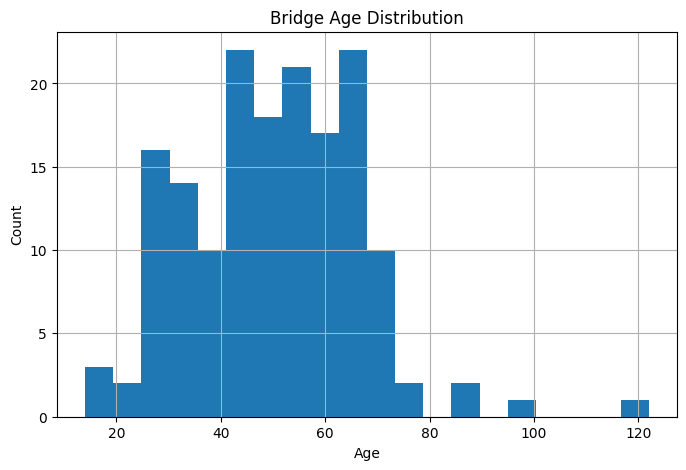

In [ ]:
plt.figure(figsize=(8,5))
df_trim["Age"].hist(bins=20)
plt.title("Bridge Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

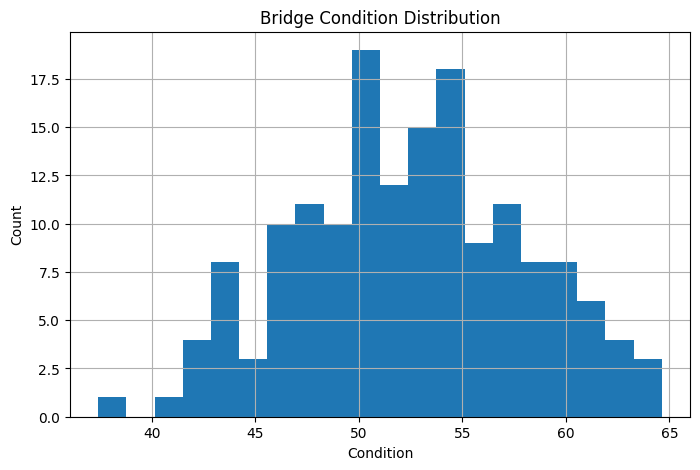

In [ ]:
plt.figure(figsize=(8,5))
df_trim["Condition"].hist(bins=20)
plt.title("Bridge Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

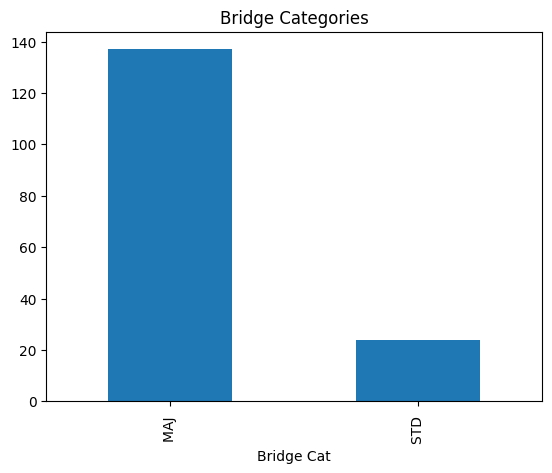

In [ ]:
df_trim["Bridge Cat"].value_counts().plot(
    kind="bar"
)

plt.title("Bridge Categories")
plt.show()

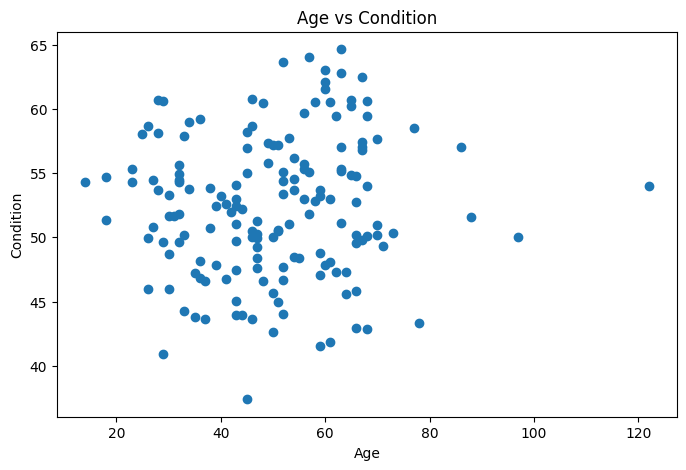

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_trim["Age"],
    df_trim["Condition"]
)

plt.xlabel("Age")
plt.ylabel("Condition")

plt.title(
    "Age vs Condition"
)

plt.show()

In [48]:
def normalize(series):
    return (
        (series - series.min()) /
        (series.max() - series.min())
    ) * 100

In [ ]:
df_trim["Condition_Score"] = normalize(
    100 - df_trim["Condition"]
)

df_trim["Age_Score"] = normalize(
    df_trim["Age"]
)

df_trim["Traffic_Score"] = normalize(
    df_trim["Traffic Volume (AADT)"]
)

df_trim["Cost_Score"] = normalize(
    df_trim["Replacement Cost ($2020)"]
)

In [ ]:
df_trim["Priority Score"] = (
      0.40 * df_trim["Condition_Score"]
    + 0.30 * df_trim["Traffic_Score"]
    + 0.20 * df_trim["Age_Score"]
    + 0.10 * df_trim["Cost_Score"]
)

In [ ]:
top10 = (
    df_trim.sort_values(
        "Priority Score",
        ascending=False
    )
    .head(10)
)

display(
    top10[
        [
            "Structure ID",
            "Priority Score",
            "Condition",
            "Age",
            "Traffic Volume (AADT)"
        ]
    ]
)

,Structure ID,Priority Score,Condition,Age,Traffic Volume (AADT)
6,B7,66.624352,47.328337,64,19965
113,B114,66.322165,47.340908,62,19596
72,B73,63.092489,46.717370,52,16226
33,B34,62.865883,43.769734,35,17795
80,B81,62.513822,45.071531,43,17235
41,B42,62.404419,49.540671,66,19556
29,B30,61.923983,50.196179,70,19134
123,B124,61.295509,47.712156,52,18821
120,B121,61.071966,45.649436,50,15440
76,B77,60.284760,37.405210,45,9422
